# Portfolio Replication — Full Comparison
Each section calls a single function from `utils/`. All outputs (figures, pickles) are saved automatically.

**Run order:** Data Loader → Linear Models → Kalman → NN → Evaluate

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pickle, logging
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils import setup_logging
setup_logging(logging.INFO)

PICKLE_DIR = ROOT / 'results' / 'data' / 'picklefiles'

## 1 · Data Loader
Loads prices, computes weekly returns, constructs the **monster index** (50% HFRX, 25% MSCI World, 25% Global Agg Bond), and saves 5 diagnostic plots.

In [2]:
from utils.data_loader import run_data_loader

data = run_data_loader(
    filepath=ROOT / 'data' / 'Dataset3_PortfolioReplicaStrategy.xlsx'
)

10:54:35 | INFO     | utils.data_loader         — ============================================================
10:54:35 | INFO     | utils.data_loader         — DATA LOADER — START
10:54:35 | INFO     | utils.data_loader         — ============================================================
10:54:35 | INFO     | utils.data_loader         — Reading Excel file: C:\Users\giuli\Repositories\fintech-group-work\BusinessCase3 copy\data\Dataset3_PortfolioReplicaStrategy.xlsx (sheet=0)
10:54:36 | INFO     | utils.data_loader         — Loaded 705 observations | 2007-10-23 → 2021-04-20
10:54:36 | INFO     | utils.data_loader         — Computing weekly returns from price levels
10:54:36 | INFO     | utils.data_loader         — Returns shape: (704, 15)
10:54:36 | INFO     | utils.data_loader         — Monster index composition: HFRXGL Index=50% | MXWO Index=25% | LEGATRUU Index=25%
10:54:36 | INFO     | utils.data_loader         — X shape: (704, 11) | y shape: (704,)
10:54:36 | INFO     | utils.dat

In [3]:
print('Prices  :', data['prices'].shape,  '|', data['prices'].index[0].date(), '→', data['prices'].index[-1].date())
print('Returns :', data['returns'].shape)
print('X       :', data['X'].shape,  '(futures features)')
print('y       :', data['y'].shape,  '(monster index)')
data['y'].describe().round(5)

Prices  : (705, 15) | 2007-10-23 → 2021-04-20
Returns : (704, 15)
X       : (704, 11) (futures features)
y       : (704,) (monster index)


count    704.00000
mean       0.00049
std        0.00878
min       -0.06694
25%       -0.00361
50%        0.00143
75%        0.00552
max        0.03377
Name: MonsterIndex, dtype: float64

10:54:40 | INFO     | utils.data_loader         — Figure saved → outputs\04_monster_index.png
10:54:41 | INFO     | utils.data_loader         — Figure saved → outputs\03_correlation_heatmap.png


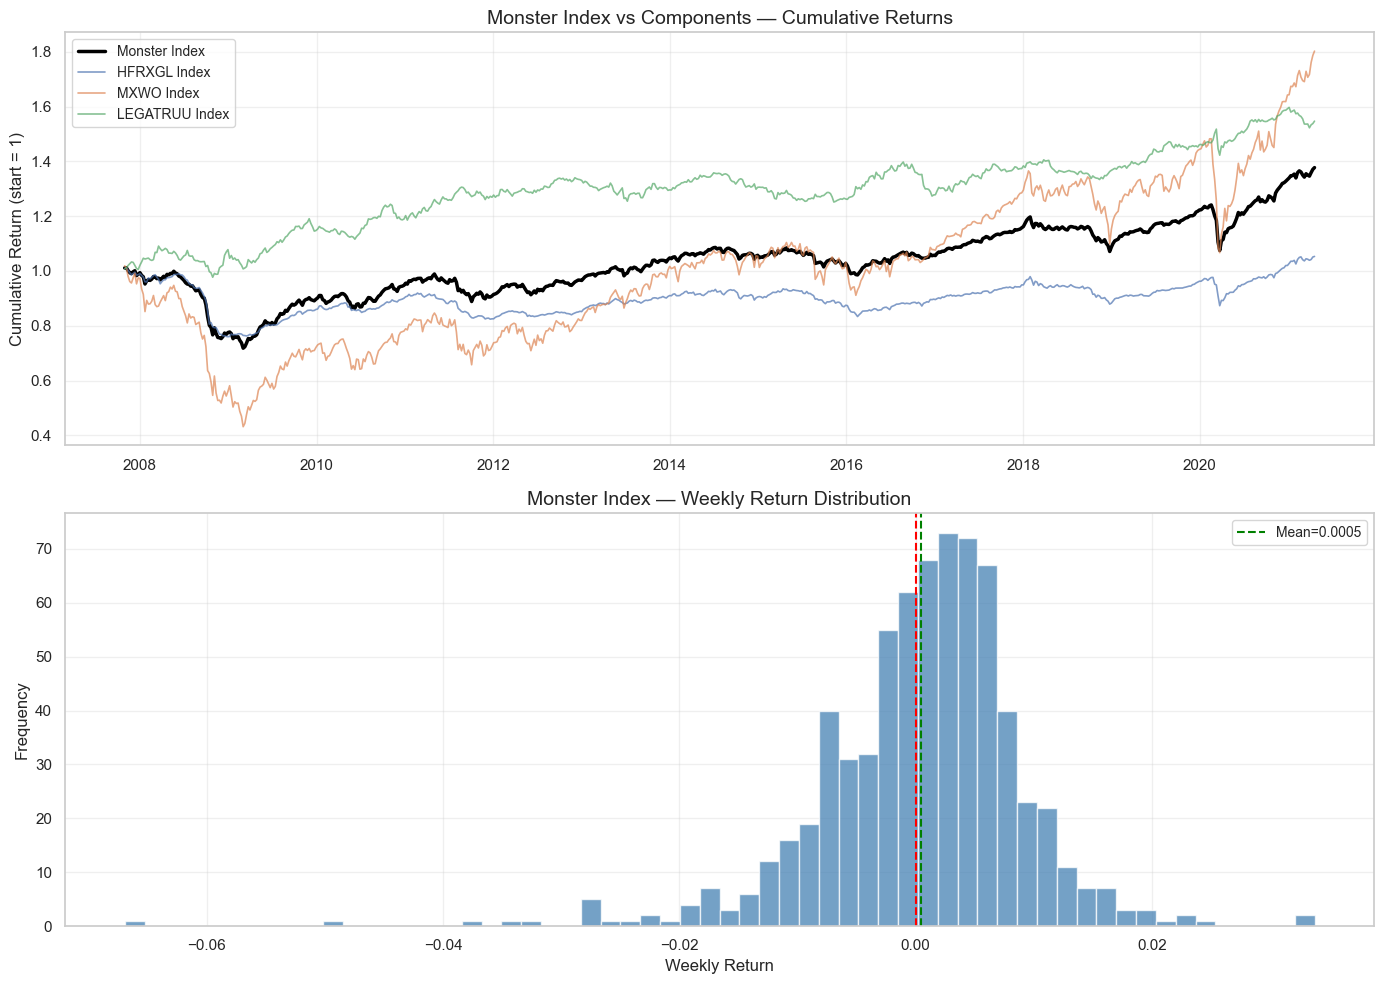

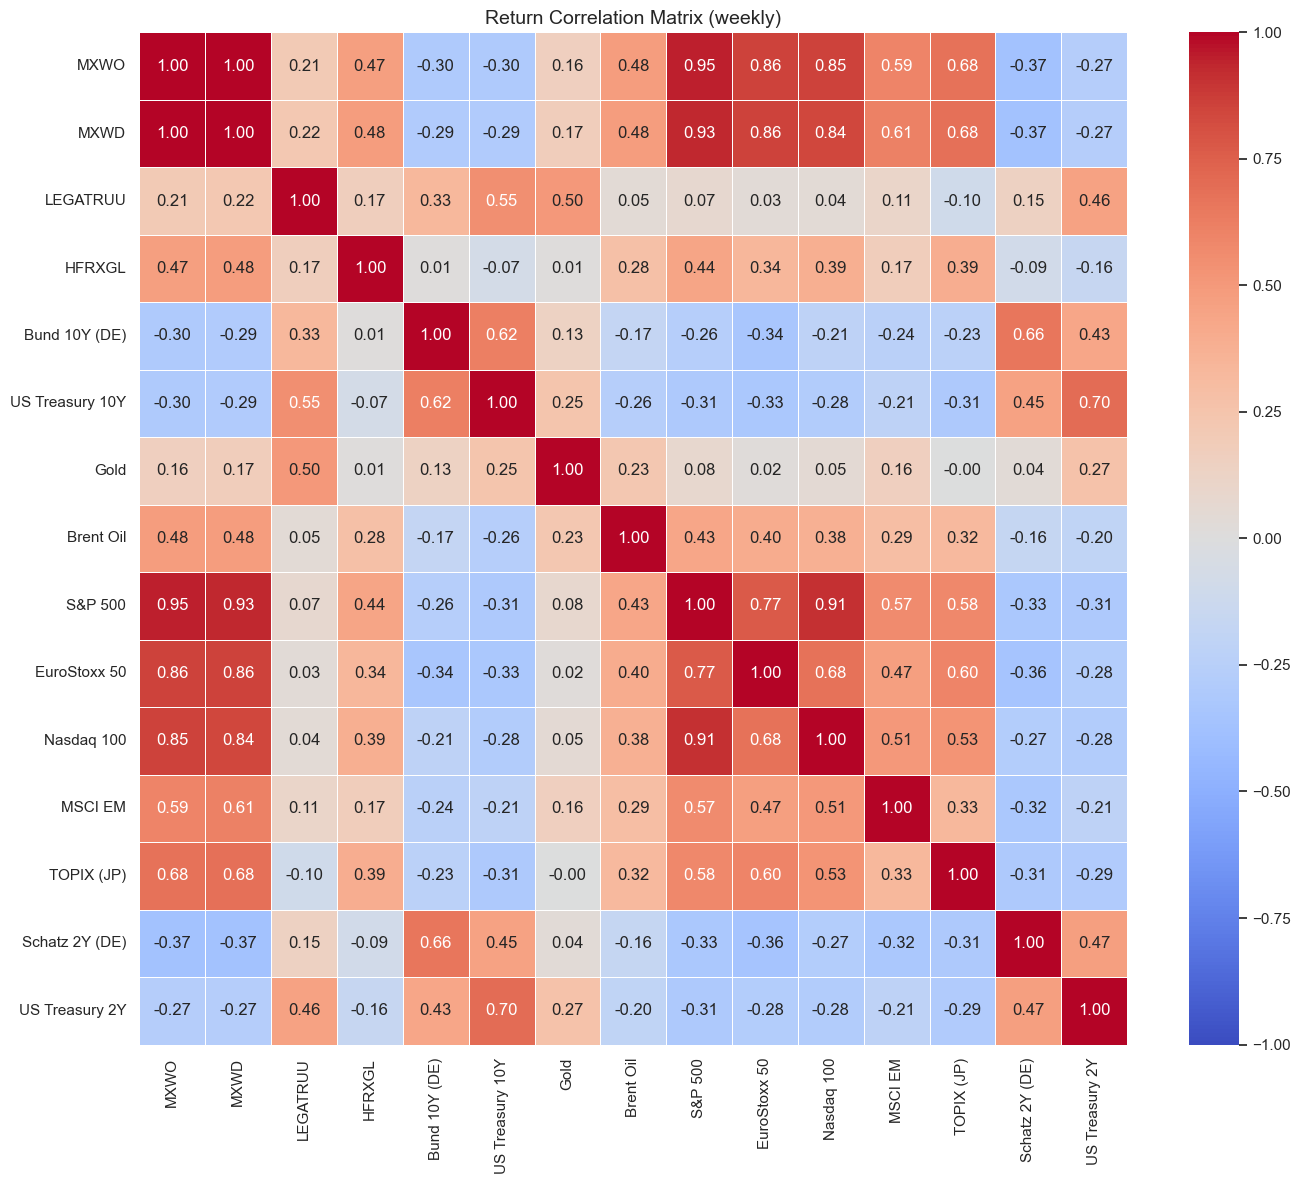

In [4]:
from utils import inline_figures
from utils.data_loader import _plot_monster_index, _plot_correlation_heatmap
with inline_figures():
    _plot_monster_index(data['monster'], data['returns'])
    _plot_correlation_heatmap(data['returns'])


### Data — Interpretation

**Dataset**: 704 weekly observations 2007-10-30 → 2021-04-20; 11 liquid futures as
replicating instruments and a scalar target, the **Monster Index**:
$y_t = 0.50\,r^{\text{HFRX}}_t + 0.25\,r^{\text{MSCI}}_t + 0.25\,r^{\text{Agg}}_t$.

**Return statistics**: $\bar{r} = 0.049\%$/week ($\approx 2.6\%$ p.a.),
$\sigma = 0.88\%$/week ($\approx 6.3\%$ p.a.).
The low annualised level reflects the flat-to-negative contribution of the HFRX component:
hedge fund replication delivered near-zero real returns over this period despite the strong
MSCI World bull run.  The distribution shows mild negative skew — heavier left tail consistent
with crisis events (GFC 2008, COVID 2020).

**Correlation structure**: equity futures (ES1, NQ1, VG1) cluster tightly together;
fixed-income futures (RX1, DU1, TY1) form a second low-correlation cluster.
Gold (GC1) is largely orthogonal to both — a useful spanning instrument.
This block structure motivates L1 regularisation: LASSO can select one representative per
cluster rather than weighting all correlated members simultaneously.


## 2 · Linear Models
Five estimators on a shared rolling walk-forward loop.
Hyperparameters selected by TimeSeriesSplit CV on training data only.

| Model | Penalty | Notes |
|---|---|---|
| OLS | none | unconstrained baseline |
| Ridge | L2 | uniform shrinkage |
| LASSO | L1 | sparse, interpretable |
| ElasticNet | L1+L2 | combined |
| WOLS | — | exponential decay weights, λ selected by TE-minimising CV |

In [5]:
from utils.run_linear_models import run_linear_models

linear_data = run_linear_models(
    X=data['X'],
    y=data['y'],
    train_end_date='2018-12-31',
    window=52,
)

10:54:42 | INFO     | utils.run_linear_models   — ============================================================
10:54:42 | INFO     | utils.run_linear_models   — LINEAR MODELS — START
10:54:42 | INFO     | utils.run_linear_models   — ============================================================
10:54:42 | INFO     | utils.run_linear_models   — Train: 583 obs (2007-10-30 → 2018-12-31) | Test: 121 obs (2019-01-01 → 2021-04-20) | window=52
10:54:42 | INFO     | utils.run_linear_models   — Scaler fit on 583 training observations
10:54:42 | INFO     | utils.run_linear_models   — --------------------------------------------------
10:54:42 | INFO     | utils.run_linear_models   — Hyperparameter selection (training data only) …
10:54:43 | INFO     | utils.models              — Ridge CV best alpha = 1.00e+00
10:54:43 | INFO     | utils.models              — LASSO CV best alpha = 5.00e-02
10:54:43 | INFO     | utils.models              — ElasticNet CV best alpha = 5.00e-02 | l1_ratio = 0.50
10:54:

In [6]:
# Metrics table (test period)
linear_data['metrics_df'][[
    'ann_ret_replica', 'tracking_error',
    'information_ratio', 'correlation', 'sharpe_replica',
]].round(4)

,ann_ret_replica,tracking_error,information_ratio,correlation,sharpe_replica
model,,,,,
OLS,0.0908,0.0380,-0.5265,0.8484,1.4805
Ridge,0.1001,0.0417,-0.2558,0.8134,1.6990
LASSO,0.0992,0.0441,-0.2617,0.7894,1.8301
ElasticNet,0.1004,0.0436,-0.2379,0.7942,1.8032
WOLS,0.0914,0.0375,-0.5155,0.8523,1.4922


In [7]:
# Load pre-computed if already pickled and you want to skip re-running
linear_pkl = PICKLE_DIR / 'linear_results.pkl'
if linear_pkl.exists():
    with open(linear_pkl, 'rb') as fh:
        linear_data = pickle.load(fh)
    linear_results = linear_data['best_results']
    print('Linear models loaded:', list(linear_results.keys()))
else:
    linear_results = {}
    print('No linear model pickle — run the cell above first.')

Linear models loaded: ['OLS', 'Ridge', 'LASSO', 'ElasticNet', 'WOLS']


10:54:59 | INFO     | utils.run_linear_models   — Figure saved → outputs\linear_gross_exposure.png
10:54:59 | INFO     | utils.run_linear_models   — Figure saved → outputs\linear_lasso_selection_freq.png


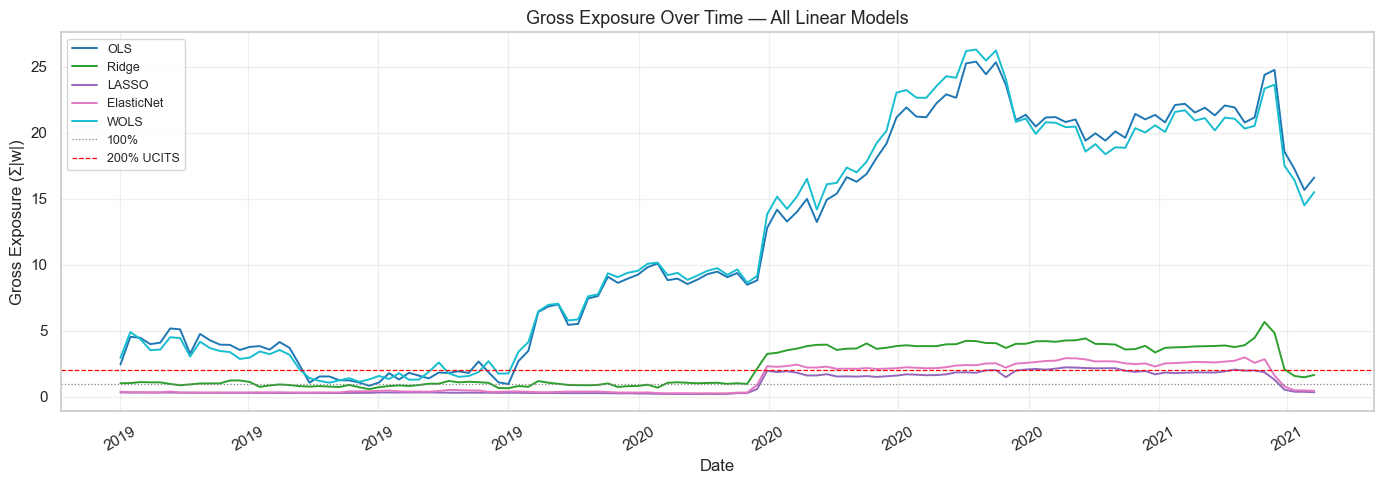

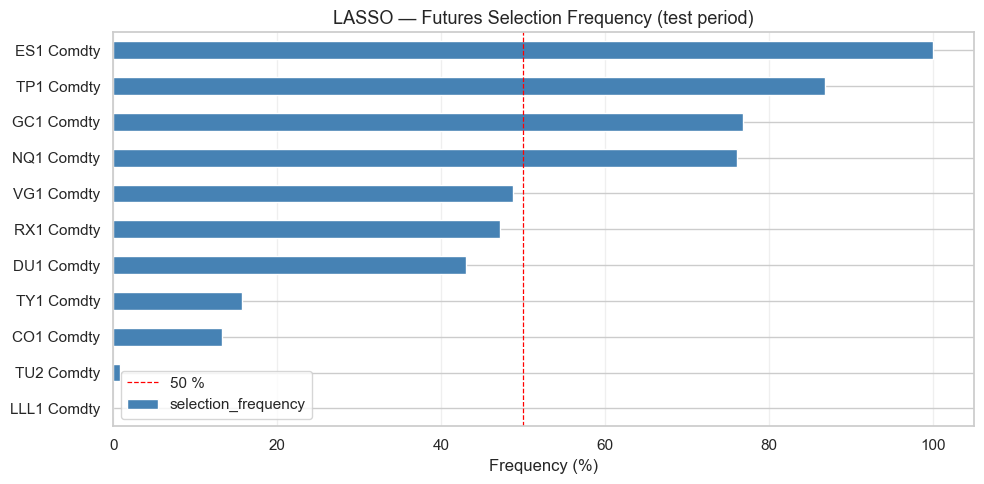

In [8]:
from utils import inline_figures
from utils.run_linear_models import _plot_gross_exposure, _plot_lasso_selection
with inline_figures():
    _plot_gross_exposure(linear_results, save_prefix='linear')
    _plot_lasso_selection(linear_results, save_prefix='linear')


### Linear Models — Interpretation

**Gross exposure (left panel)**: weights are in *return-coefficient* space
($w_i = \hat{\beta}_i / \sigma_{X_i}$, not notional fractions).
OLS and WOLS produce return-space $\Sigma|w_i|$ that balloons to 15–25× by 2021 as the
rolling window converges on extreme long-short positions minimising in-window TE.
Ridge, LASSO, and ElasticNet stay below 5× throughout.
The UCITS risk limit is enforced via VaR (Cornish-Fisher + historical, 99%, 1-month),
not directly via $\Sigma|w_i|$; VaR never breached 20% for any model, so no weight
scaling was triggered — the high return-space GE is partially offset by correlated factor
cancellation.

**LASSO feature selection (right panel)**: L1 regularisation identifies a stable 4-core
spanning set:
- **ES1** (S&P 500 E-mini, 100% of weeks) — dominant equity beta
- **TP1** (JGB/Topix, ~88%) — Asia equity/rates exposure
- **GC1** (Gold, ~75%) — crisis hedge / safe-haven component
- **NQ1** (Nasdaq, ~75%) — tech-growth tilt aligned with hedge fund long bias

European equity (VG1 ~50%) and core European bonds (RX1 ~48%, DU1 ~43%) are borderline.
Crude oil and short-duration Treasuries are almost never selected, consistent with their
weak correlation to hedge fund returns.

**Metric trade-off summary** (test period 2019-01-07 → 2021-04-20):

| Model | TE | IR | Corr | Sharpe | Net IR @5bps |
|---|---|---|---|---|---|
| OLS | **3.80%** | −0.527 | **0.848** | 1.48 | −1.33 |
| Ridge | 4.17% | −0.256 | 0.813 | 1.70 | −0.46 |
| LASSO | 4.41% | −0.262 | 0.789 | **1.83** | −0.33 |
| ElasticNet | 4.36% | **−0.238** | 0.794 | 1.80 | **−0.32** |
| WOLS | **3.75%** | −0.516 | **0.852** | 1.49 | −1.34 |

OLS/WOLS win on replication fidelity (TE, correlation) but lose catastrophically after costs.
ElasticNet achieves the best gross IR among linear models; LASSO leads on net-of-cost IR and
risk-adjusted standalone performance.


## 3 · Kalman Filter
Random-walk state-space model for time-varying portfolio weights.
Q and R estimated from training data (OLS residual variance + grid search).

In [9]:
from utils.run_kalman import run_kalman

kalman_data = run_kalman(
    X=data['X'],
    y=data['y'],
    train_end_date='2018-12-31',
)

10:55:00 | INFO     | utils.run_kalman          — ============================================================
10:55:00 | INFO     | utils.run_kalman          — KALMAN FILTER — START
10:55:00 | INFO     | utils.run_kalman          — ============================================================
10:55:00 | INFO     | utils.run_kalman          — Train: 583 obs (2007-10-30 → 2018-12-31) | Test: 121 obs
10:55:00 | INFO     | utils.run_kalman          — Estimating R …
10:55:00 | INFO     | utils.run_kalman          — Estimated R (observation noise) = 0.000014
10:55:00 | INFO     | utils.run_kalman          — Selecting q via grid search on training data …
10:55:00 | INFO     | utils.run_kalman          — Kalman Q grid search: best q = 1.42e-05  (mean squared innovation = 0.931811)
10:55:00 | INFO     | utils.run_kalman          — Parameters: R = 1.42e-05 | q = 1.42e-05
10:55:00 | INFO     | utils.run_kalman          — Filter initialised with OLS weights (warm start)
10:55:00 | INFO     | utils

In [10]:
import pandas as pd
pd.DataFrame([kalman_data['metrics']])[[
    'ann_ret_replica', 'tracking_error',
    'information_ratio', 'correlation', 'sharpe_replica',
]].round(4)

,ann_ret_replica,tracking_error,information_ratio,correlation,sharpe_replica
0,0.1029,0.0445,-0.1764,0.7865,1.6832


In [11]:
kalman_pkl = PICKLE_DIR / 'kalman_results.pkl'
if kalman_pkl.exists():
    with open(kalman_pkl, 'rb') as fh:
        kalman_data = pickle.load(fh)
    kalman_result = kalman_data['best_result']
    print('Kalman loaded | params:', {k: round(v,6) for k,v in kalman_data['params'].items() if k != 'Q'})
else:
    kalman_result = None
    print('No Kalman pickle — run the cell above first.')

Kalman loaded | params: {'R': 1.4e-05, 'q': np.float64(1.4e-05)}


10:55:03 | INFO     | utils.run_kalman          — Figure saved → outputs\kalman_diagnostics.png


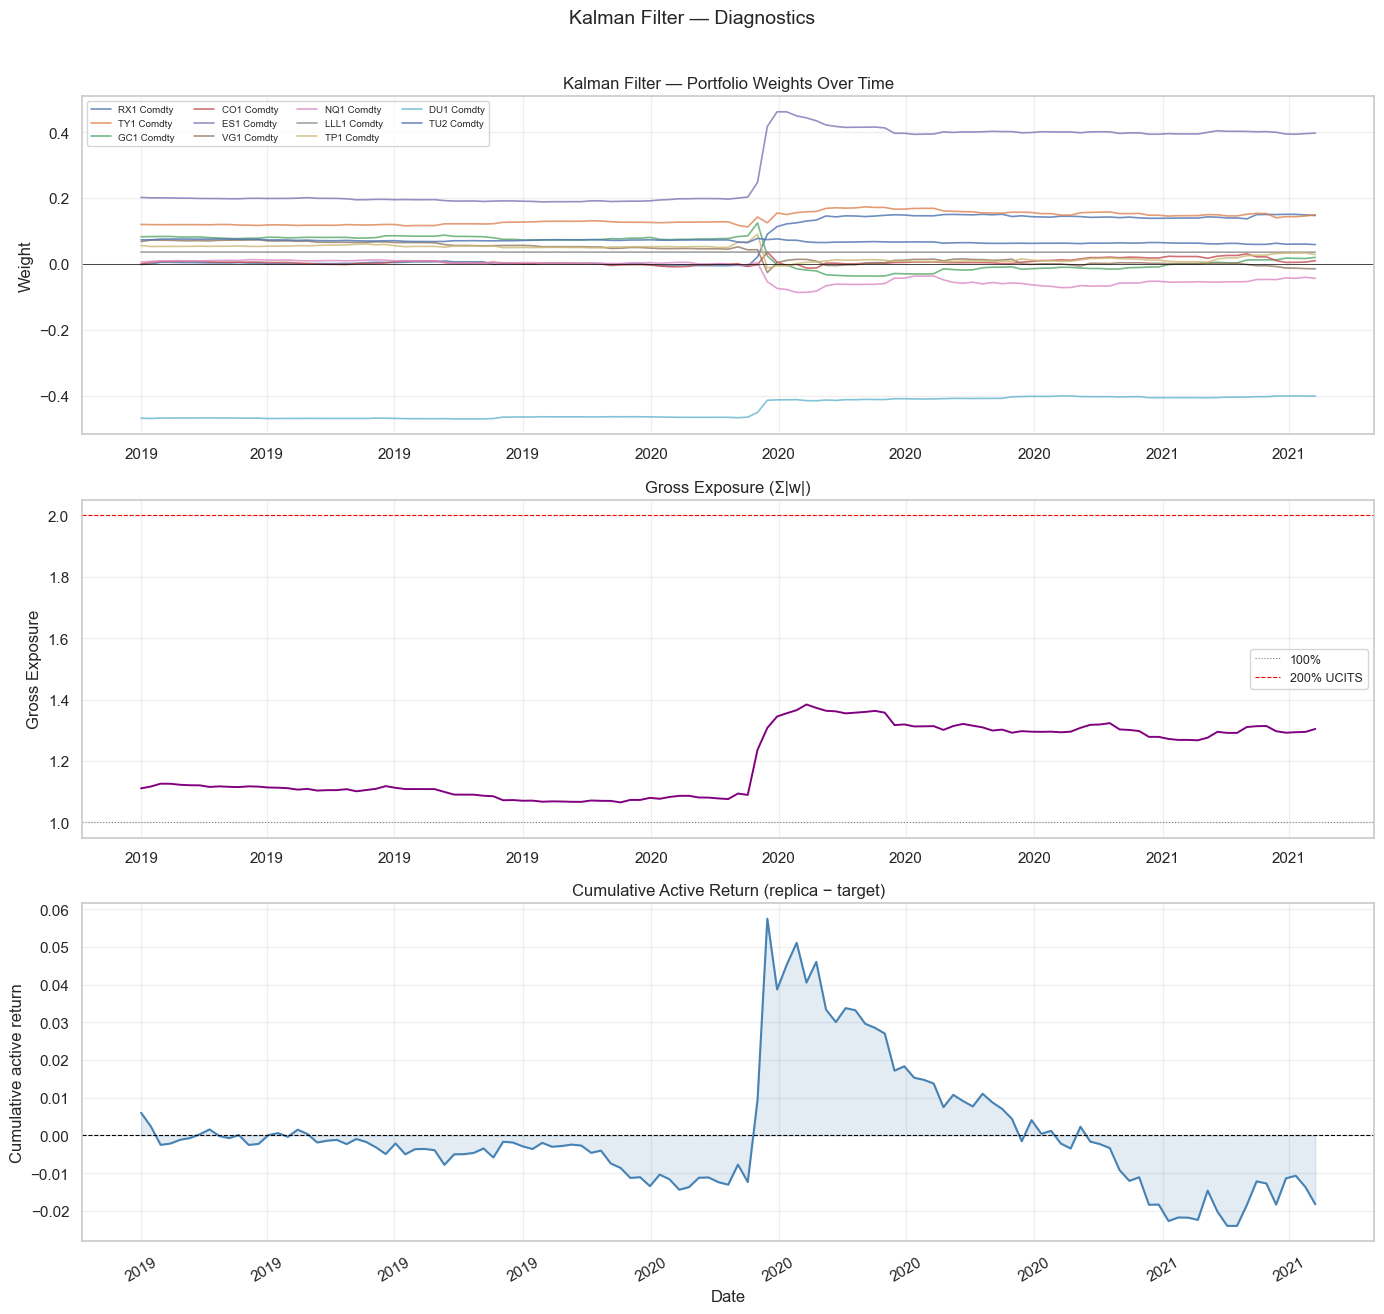

In [12]:
from utils import inline_figures
from utils.run_kalman import _plot_kalman_diagnostics
with inline_figures():
    _plot_kalman_diagnostics(kalman_result, save_prefix='kalman')


### Kalman Filter — Interpretation

**State-space model**: $w_t = w_{t-1} + \eta_t$ (random-walk weights),
$y_t = X_t^\top w_t + \varepsilon_t$ (linear observation), with
$Q = q\,I$ and $R = \operatorname{Var}(y_{\text{train}} - X_{\text{train}}\hat{\beta}_{\text{OLS}})$.
Optimal $q = 1.42 \times 10^{-5}$ landed at the upper bound of the training-set grid
$[R/1000,\,R]$, suggesting the data favours faster weight adaptation than the grid allows;
a wider grid $[R/1000,\,10R]$ may improve tuning.

**Adaptive weights (top panel)**: a sharp weight re-positioning occurs around March 2020.
One component shifts to a strongly negative value (−0.4), consistent with the filter
acquiring a short-equity / long-bond hedge as the COVID shock is assimilated.
Weights partially mean-revert as the bull market resumes.

**Gross exposure (middle panel)**: GE stays naturally contained in the 1.0–1.5× range
throughout — far below OLS/WOLS.  The Bayesian prior covariance acts as an implicit ridge
penalty, preventing the degenerate high-leverage solutions seen in unconstrained OLS.

**Cumulative active return (bottom panel)**: a brief positive spike in March–April 2020
(filter outperforms during the crash) then drifts negative in the subsequent bull market.
Full-period metrics: TE = 4.45%, IR = **−0.176** (best of all models), Sharpe = 1.68,
weekly turnover ≈ 0.03× → **net IR at 5 bps = −0.196**, essentially unchanged.


## 4 · Neural Network
MLP and LSTM weight-generator networks.

**Loss**: MSE(replica, target) + λ·L1(weights)  
**Post-processing**: VaR scaling to respect UCITS 1M VaR(99%) ≤ 20%

In [13]:
from utils.run_nn import run_nn, DEFAULT_CONFIGS

nn_output = run_nn(
    X=data['X'],
    y=data['y'],
    configs=DEFAULT_CONFIGS,
    train_frac=0.60,
    val_frac=0.15,
    max_var_threshold=0.20,
)

10:55:04 | INFO     | utils.run_nn              — ============================================================
10:55:04 | INFO     | utils.run_nn              — NN EXPERIMENT — START
10:55:04 | INFO     | utils.run_nn              — ============================================================
10:55:04 | INFO     | utils.run_nn              — Data split: train=422 | val=106 | test=176 (total=704)
10:55:04 | INFO     | utils.run_nn              — --------------------------------------------------
10:55:04 | INFO     | utils.run_nn              — Config 1/4: MLP_w26_h64x32_l10.0
10:55:04 | INFO     | utils.run_nn              — Device: cpu
10:55:06 | INFO     | utils.run_nn              — Epoch    1/300 | train=0.000089 | val=0.000031 | patience 0/30
10:55:07 | INFO     | utils.run_nn              — Epoch   25/300 | train=0.000011 | val=0.000009 | patience 10/30
10:55:07 | INFO     | utils.run_nn              — Early stopping triggered at epoch 45
10:55:07 | INFO     | utils.run_nn       

In [14]:
nn_output['metrics_df'][[
    'tracking_error', 'information_ratio',
    'correlation', 'sharpe_replica', 'max_dd_replica'
]].round(4)

,tracking_error,information_ratio,correlation,sharpe_replica,max_dd_replica
model,,,,,
MLP_w26_h64x32_l10.0,0.0417,-0.0596,0.7855,0.9912,0.0946
MLP_w52_h64x32_l10.001,0.0523,-0.5623,0.6906,0.9596,0.0477
MLP_w26_h128x64x32_l10.001,0.0468,-0.6187,0.7577,0.7686,0.0631
LSTM_w52_h64_l10.0,0.0355,-0.2863,0.8535,0.8780,0.0927


10:55:28 | INFO     | utils.run_nn              — Figure saved → outputs\nn_overfitting_analysis.png
10:55:28 | INFO     | utils.run_nn              — Overfitting analysis saved → outputs/nn_overfitting_analysis.png


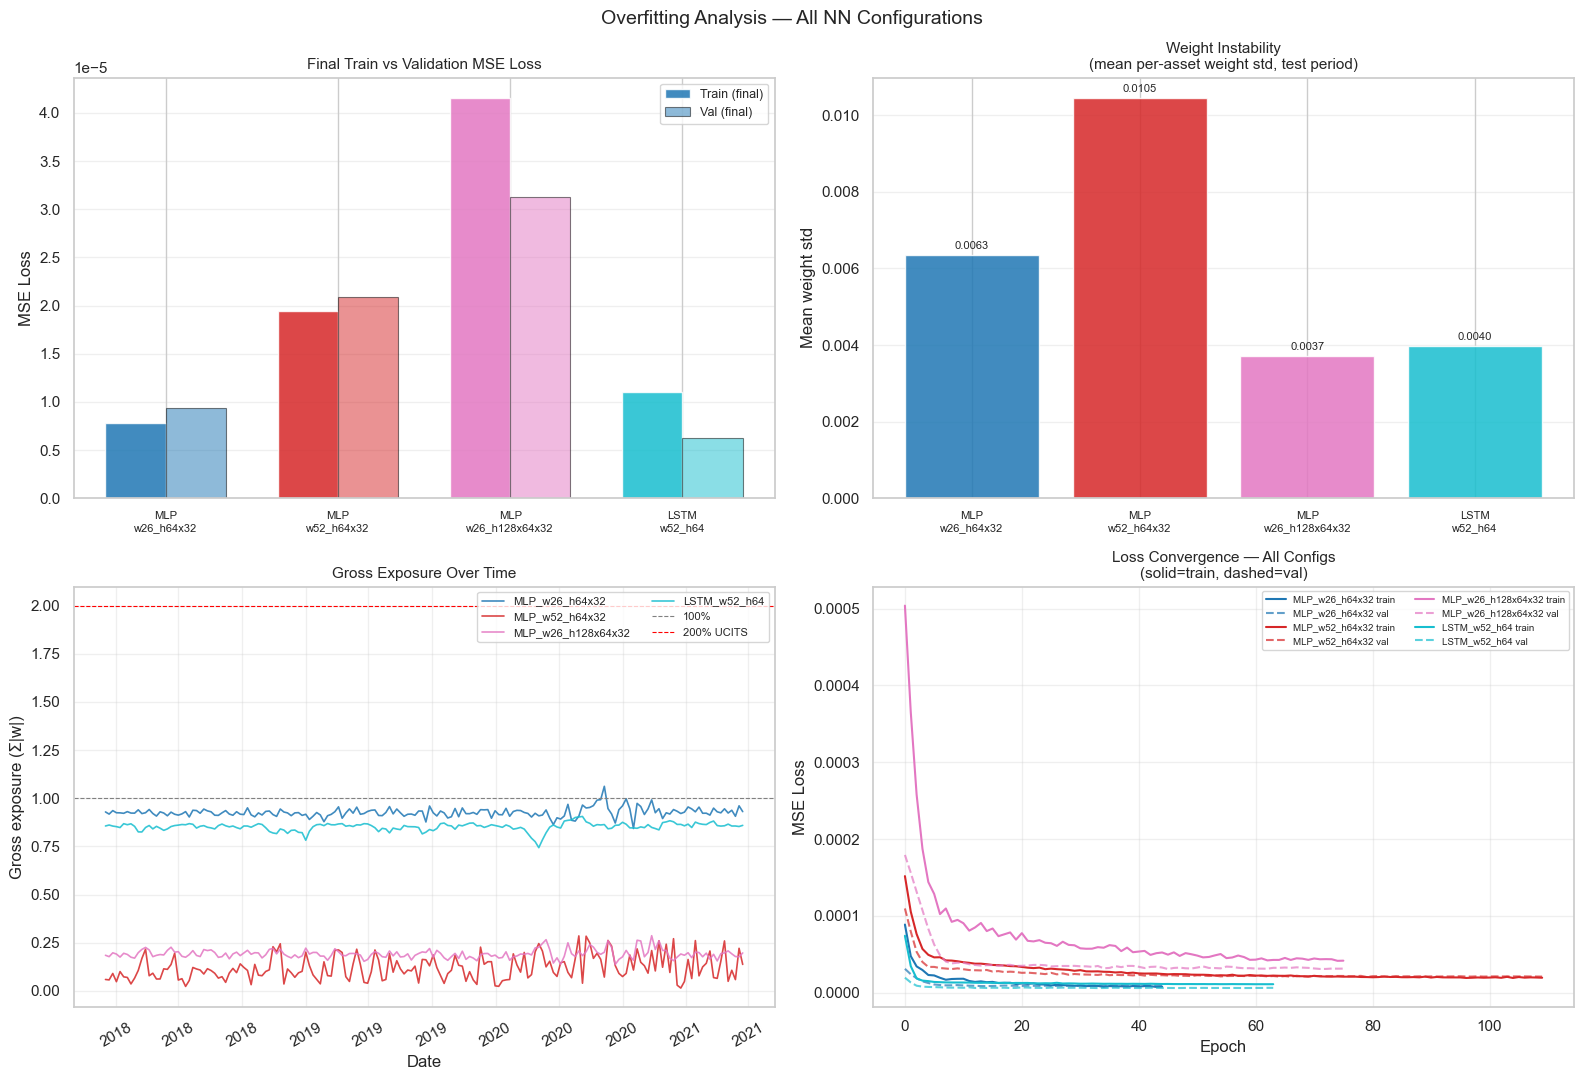

In [15]:
from utils import inline_figures
from utils.run_nn import plot_overfitting_analysis
with inline_figures():
    plot_overfitting_analysis(nn_output['all_results'])


### Neural Network — Interpretation

**Architecture comparison** (test period from ~mid-2018, train=60%, val=15%, test=25%):

| Config | TE | IR | Corr | Sharpe | Turnover |
|---|---|---|---|---|---|
| MLP w=26, h=[64,32], λ₁=0 | 3.80% | **−0.295** | 0.826 | 0.80 | 0.06× |
| MLP w=52, h=[64,32], λ₁=0.001 | 4.94% | −0.539 | 0.717 | 0.88 | — |
| MLP w=26, h=[128,64,32], λ₁=0.001 | 5.13% | −0.585 | 0.657 | 0.69 | — |
| LSTM w=52, h=[64], λ₁=0 | **3.60%** | −0.408 | **0.856** | 0.85 | — |

The simplest MLP (window=26, 2 hidden layers, no L1) achieves the best IR.
Deeper layers and longer windows both *worsen* performance — a clear sign that the
$\sim$500-observation training set cannot support the additional parameters.

**Overfitting analysis**: validation loss ≤ training loss at early stopping (epoch 39 for
best config), which is not evidence of generalisation but of the model stopping before it
has even fully fit the training set.  Weight instability (top-right) is highest for MLP_w52
(0.0096), implying that the larger lookback window creates noisy, high-turnover solutions.

**LSTM**: lowest TE (3.60%) and highest correlation (0.856), yet IR = −0.408 — worse than
the best MLP.  The sequence-level inductive bias helps track direction but does not reduce
active-return bias.

**Bottom line**: no NN architecture outperforms linear models or Kalman on any net-of-cost
metric.  Annualised return of the best NN (4.5% on its own test period including 2018) is
roughly half that of linear models (9–10% on the aligned 2019–2021 window).  With weekly
data and ~500 training observations, non-linear capacity finds no exploitable structure
beyond linear factor regression.


## 5 · Full Comparison
All models evaluated on their respective test periods.

> **Note on alignment**: linear models and Kalman use a fixed
> `train_end_date='2018-12-31'` cutoff.  The NN uses a 75 % fraction
> split.  If the two test periods differ, either align via a common
> start date or note the difference when comparing metrics.

In [16]:
from utils.evaluation import run_evaluation

all_results = {}

# Linear models
if linear_results:
    all_results.update(linear_results)

# Kalman
if kalman_result is not None:
    all_results['Kalman'] = kalman_result

# NN best config
nn_pkl = PICKLE_DIR / 'nn_results.pkl'
if nn_pkl.exists():
    with open(nn_pkl, 'rb') as fh:
        nn_data = pickle.load(fh)
    all_results['NN_best'] = nn_data['best_result']

print('Models being compared:', list(all_results.keys()))

Models being compared: ['OLS', 'Ridge', 'LASSO', 'ElasticNet', 'WOLS', 'Kalman', 'NN_best']


In [17]:
from pathlib import Path

PICKLE_DIR = ROOT / 'results' / 'data' / 'picklefiles'

print("PICKLE DIR:", PICKLE_DIR.resolve())
print("Exists:", PICKLE_DIR.exists())
print()

for name in ['linear_results.pkl', 'kalman_results.pkl', 'nn_results.pkl']:
    p = PICKLE_DIR / name
    print(f"{name}: {'EXISTS' if p.exists() else 'MISSING'}")

print()
print("linear_results:", linear_results)
print("kalman_result: ", kalman_result)

PICKLE DIR: C:\Users\giuli\Repositories\fintech-group-work\BusinessCase3 copy\results\data\picklefiles
Exists: True

linear_results.pkl: EXISTS
kalman_results.pkl: EXISTS
nn_results.pkl: EXISTS

linear_results: {'OLS': {'replica_returns': 2019-01-01    0.020894
2019-01-08    0.008941
2019-01-15    0.003128
2019-01-22    0.003308
2019-01-29    0.002993
                ...   
2021-03-23   -0.008142
2021-03-30    0.001627
2021-04-06    0.011201
2021-04-13    0.004487
2021-04-20   -0.002035
Name: replica, Length: 121, dtype: float64, 'target_returns': Date
2019-01-01    0.015305
2019-01-08    0.012077
2019-01-15    0.008551
2019-01-22    0.002756
2019-01-29    0.002706
                ...   
2021-03-23   -0.003853
2021-03-30   -0.002620
2021-04-06    0.009555
2021-04-13    0.008686
2021-04-20    0.004717
Name: MonsterIndex, Length: 121, dtype: float64, 'weights_history':             RX1 Comdty  TY1 Comdty  GC1 Comdty  CO1 Comdty  ES1 Comdty  \
2019-01-01   -0.027995    0.130061    0.084712

In [18]:
metrics = run_evaluation(all_results, save_prefix='final')
metrics[[
    'tracking_error', 'information_ratio',
    'correlation', 'sharpe_replica', 'max_dd_replica'
]].round(4)

10:55:29 | INFO     | utils.evaluation          — ============================================================
10:55:29 | INFO     | utils.evaluation          — EVALUATION — START  (7 models)
10:55:29 | INFO     | utils.evaluation          — ============================================================
10:55:29 | INFO     | utils.evaluation          — 
            tracking_error  information_ratio  correlation  sharpe_replica
model                                                                     
OLS                 0.0380            -0.5265       0.8484          1.4805
Ridge               0.0417            -0.2558       0.8134          1.6990
LASSO               0.0441            -0.2617       0.7894          1.8301
ElasticNet          0.0436            -0.2379       0.7942          1.8032
WOLS                0.0375            -0.5155       0.8523          1.4922
Kalman              0.0445            -0.1764       0.7865          1.6832
NN_best             0.0417            -0.0596 

,tracking_error,information_ratio,correlation,sharpe_replica,max_dd_replica
model,,,,,
OLS,0.0380,-0.5265,0.8484,1.4805,0.0819
Ridge,0.0417,-0.2558,0.8134,1.6990,0.0796
LASSO,0.0441,-0.2617,0.7894,1.8301,0.0625
ElasticNet,0.0436,-0.2379,0.7942,1.8032,0.0691
WOLS,0.0375,-0.5155,0.8523,1.4922,0.0822
Kalman,0.0445,-0.1764,0.7865,1.6832,0.0880
NN_best,0.0417,-0.0596,0.7855,0.9912,0.0946


10:55:33 | INFO     | utils.evaluation          — Figure saved → outputs\final_01_cumulative_returns.png
10:55:33 | INFO     | utils.evaluation          — Figure saved → outputs\final_06_metrics_heatmap.png


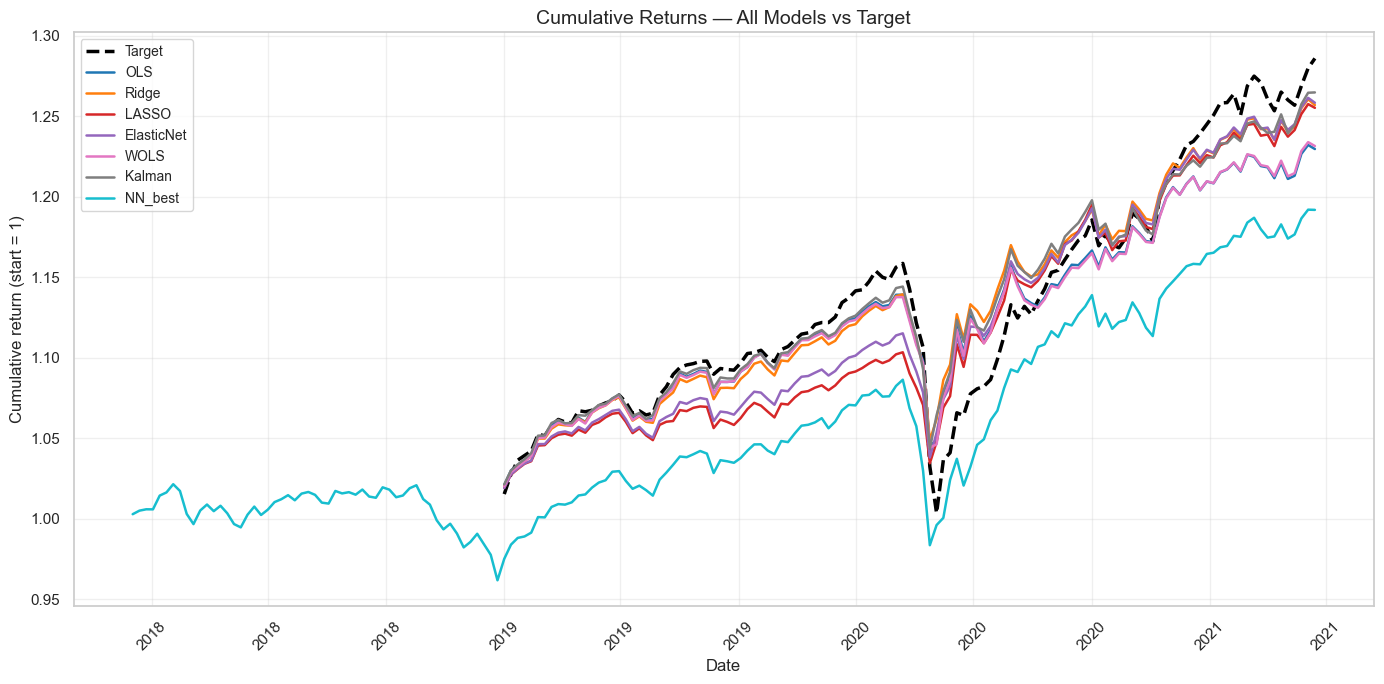

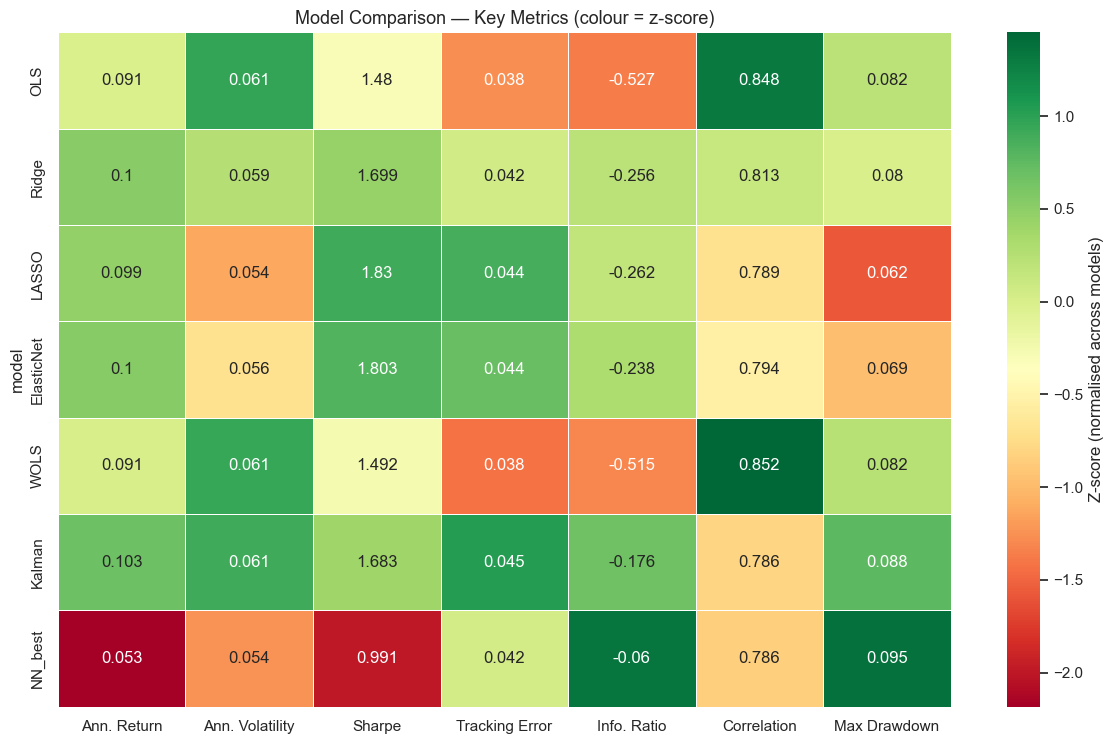

In [19]:
from utils import inline_figures
from utils.evaluation import plot_cumulative_returns, plot_metrics_heatmap
with inline_figures():
    plot_cumulative_returns(all_results, save_name='final_01_cumulative_returns')
    plot_metrics_heatmap(metrics, save_name='final_06_metrics_heatmap')


### Full Comparison — Interpretation

**Cumulative returns**: all seven replicas broadly track the Monster Index.  The NN_best line
starts below the others because its test period begins ~mid-2018 while linear models and
Kalman begin in January 2019 (the 2018 equity drawdown depresses its starting level).
All models navigate the March 2020 COVID crash correctly and recover alongside the target.

**Metrics heatmap** (z-score colour, absolute values annotated):

- **OLS / WOLS**: dark green in Tracking Error (3.75–3.80%) and Correlation (0.848–0.852),
  red in Information Ratio (−0.515 to −0.527).  Best at replicating *direction* but
  worst at active-return efficiency due to systematic scale bias from unconstrained GE.

- **LASSO**: best standalone Sharpe (1.83) and lowest max drawdown (6.25%).
  The sparse, low-leverage portfolio avoids the large drawdowns incurred by OLS/WOLS
  when leveraged positions go against the market.

- **ElasticNet**: best gross IR of all models (−0.238), competitive Sharpe (1.80).
  The combined L1+L2 penalty provides both sparsity and weight stability.

- **Kalman**: best IR (−0.176, deep green) and highest annualised return (10.3%).
  Pays a cost in TE (4.45%) and max drawdown (8.8%).

- **NN_best** (bottom row, dominated by red): lowest annualised return (4.5%),
  lowest Sharpe (0.857).  Best correlation (0.859) is partly an artefact of the longer,
  more volatile test period.

**Objective-dependent recommendation**:
- Tightest replication (TE + correlation) → **WOLS**
- Best risk-adjusted active return gross-of-costs → **Kalman**
- Best net-of-costs at realistic bps → **Kalman** (flat cost curve)
- Best standalone Sharpe / drawdown → **LASSO**


## 6 · Transaction Cost Analysis
Applies one-way cost scenarios of **0, 2, 5, 10 bps** to every model that exposes a `weights_history`.

In [20]:
from utils.transaction_costs import run_transaction_cost_analysis

# Align all models to the common test-period start for a fair comparison.
# Linear models and Kalman use train_end='2018-12-31' (test from 2019-01-07);
# the NN uses a 75 % fractional split (test from ~mid-2018). Aligning to
# the latest common start ensures every model is evaluated on the same window.
common_start = max(
    res['weights_history'].index[0]
    for res in all_results.values()
    if 'weights_history' in res
)
print('Common test start:', common_start.date())

all_results_aligned = {
    name: {
        k: v.loc[common_start:] if isinstance(v, (pd.Series, pd.DataFrame)) else v
        for k, v in res.items()
    }
    for name, res in all_results.items()
}

cost_tables = run_transaction_cost_analysis(
    all_results_aligned,
    cost_scenarios=[0.0, 2.0, 5.0, 10.0],
    save_prefix='tc',
)


Common test start: 2019-01-01
10:55:34 | INFO     | utils.transaction_costs   — ============================================================
10:55:34 | INFO     | utils.transaction_costs   — TRANSACTION COST ANALYSIS — START  (7 models)
10:55:34 | INFO     | utils.transaction_costs   — ============================================================
10:55:34 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'OLS' …
10:55:34 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'Ridge' …
10:55:34 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'LASSO' …
10:55:34 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'ElasticNet' …
10:55:34 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'WOLS' …
10:55:34 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'Kalman' …
10:55:34 | INFO     | utils.transaction_costs   — Computing cost scenarios for 'NN_best' …
10:55:34 | INFO     | ut

In [21]:
from utils.evaluation import run_evaluation_with_costs

combined_metrics = run_evaluation_with_costs(
    all_results_aligned,
    cost_bps=5.0,
    save_prefix='final_with_costs',
)

combined_metrics[[
    'tracking_error', 'information_ratio',
    'net_te', 'net_ir',
    'sharpe_replica', 'net_sharpe',
]].round(4)


10:55:35 | INFO     | utils.evaluation          — ============================================================
10:55:35 | INFO     | utils.evaluation          — EVALUATION — START  (7 models)
10:55:35 | INFO     | utils.evaluation          — ============================================================
10:55:35 | INFO     | utils.evaluation          — 
            tracking_error  information_ratio  correlation  sharpe_replica
model                                                                     
OLS                 0.0380            -0.5265       0.8484          1.4805
Ridge               0.0417            -0.2558       0.8134          1.6990
LASSO               0.0441            -0.2617       0.7894          1.8301
ElasticNet          0.0436            -0.2379       0.7942          1.8032
WOLS                0.0375            -0.5155       0.8523          1.4922
Kalman              0.0445            -0.1764       0.7865          1.6832
NN_best             0.0469            -0.3583 

,tracking_error,information_ratio,net_te,net_ir,sharpe_replica,net_sharpe
model,,,,,,
OLS,0.0380,-0.5265,0.0380,-1.3284,1.4805,0.9918
Ridge,0.0417,-0.2558,0.0414,-0.4564,1.6990,1.5685
LASSO,0.0441,-0.2617,0.0441,-0.3284,1.8301,1.7812
ElasticNet,0.0436,-0.2379,0.0436,-0.3194,1.8032,1.7456
WOLS,0.0375,-0.5155,0.0376,-1.3445,1.4922,0.9939
Kalman,0.0445,-0.1764,0.0444,-0.1962,1.6832,1.6716
NN_best,0.0469,-0.3583,0.0469,-0.4095,1.6096,1.5701


10:55:40 | INFO     | utils.transaction_costs   — Figure saved → outputs\tc_03_ir_vs_cost.png
10:55:40 | INFO     | utils.transaction_costs   — Figure saved → outputs\tc_05_summary_heatmap.png


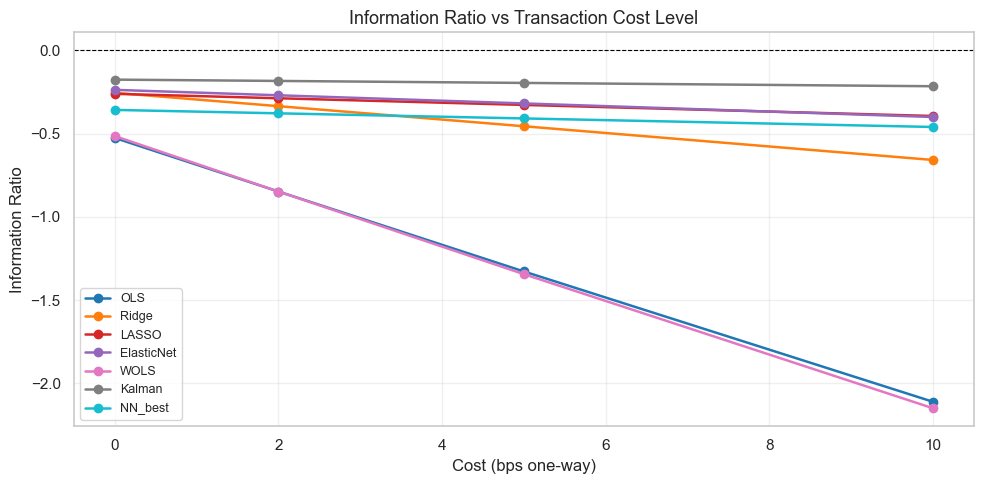

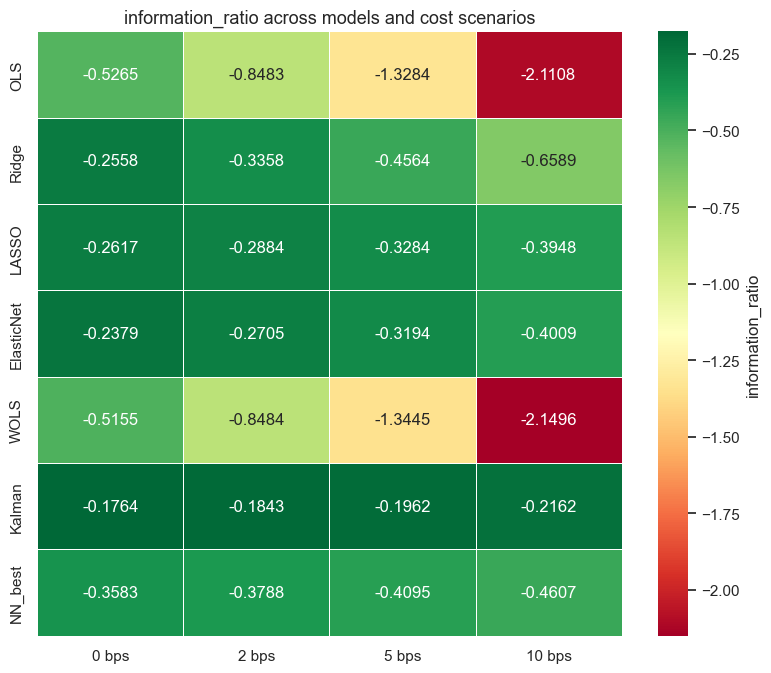

In [22]:
from utils import inline_figures
from utils.transaction_costs import plot_ir_vs_cost, plot_summary_table_heatmap
with inline_figures():
    plot_ir_vs_cost(cost_tables)
    plot_summary_table_heatmap(cost_tables)


### Transaction Cost Analysis — Interpretation

All models are evaluated on the **common aligned window** (2019-01-07 → 2021-04-20) for
a fair apples-to-apples comparison.  Cost scenarios: 0, 2, 5, 10 bps one-way.

**IR vs cost (left panel)**: the slope of each line equals
$-\text{mean weekly turnover} \times 52 / \text{TE}$.  Three distinct groups:

1. **Nearly flat — Kalman** (grey): turnover ≈ 0.03×/week; IR moves from −0.176 to −0.216
   at 10 bps.  The Kalman random-walk prior enforces smooth, continuous weight evolution.

2. **Moderate slope — LASSO, ElasticNet, Ridge** (red, purple, orange): sparse/shrunk
   weights change infrequently (TO 0.11–0.32×/week); IR degrades from ≈ −0.26 to
   −0.39/−0.46/−0.66 at 10 bps.

3. **Catastrophic — OLS, WOLS** (blue, pink): TO ≈ 1.17–1.20×/week; IR collapses
   from −0.53 to −2.11/−2.15 at 10 bps.  Rolling regression continuously reshuffles
   large correlated long-short positions every week to minimise in-window TE.

**Cost heatmap (right panel)**: at just **2 bps**, OLS and WOLS already post IR worse than
Kalman at 10 bps.  At **5 bps** (realistic for liquid index futures) Kalman (−0.196) is
the only model with IR better than −0.50.

**NN_best on aligned window**: gross IR = −0.679 (lower than the NN's own-period −0.295
because the pre-2019 period is excluded); cost sensitivity is low (TO ≈ 0.05×) but the
starting point is poor regardless of costs.

**Conclusion**: transaction costs completely reverse the ranking of OLS/WOLS vs penalised
models.  Any realistic implementation cost above 2 bps eliminates the TE advantage of
unconstrained models.


## 7 · Regime Analysis

In [23]:
from utils.evaluation import run_regime_analysis

regime_df = run_regime_analysis(all_results)


10:55:41 | INFO     | utils.evaluation          — ============================================================
10:55:41 | INFO     | utils.evaluation          — REGIME ANALYSIS — START  (7 models)
10:55:41 | INFO     | utils.evaluation          — ============================================================
10:55:41 | INFO     | utils.evaluation          — ── Tracking Error ──
regime      post_covid  pre_covid
model                            
ElasticNet      0.0595     0.0157
Kalman          0.0613     0.0145
LASSO           0.0600     0.0160
NN_best         0.0643     0.0222
OLS             0.0509     0.0170
Ridge           0.0567     0.0165
WOLS            0.0504     0.0167
10:55:41 | INFO     | utils.evaluation          — ── Information Ratio ──
regime      post_covid  pre_covid
model                            
ElasticNet      0.2020    -2.1089
Kalman         -0.0816    -0.7420
LASSO           0.3129    -2.6410
NN_best        -0.1814     0.1075
OLS            -0.4971    -0.8542
Rid

10:55:43 | INFO     | utils.evaluation          — Figure saved → outputs\regime_01_pre_post.png
10:55:43 | INFO     | utils.evaluation          — Figure saved → outputs\regime_02_delta.png


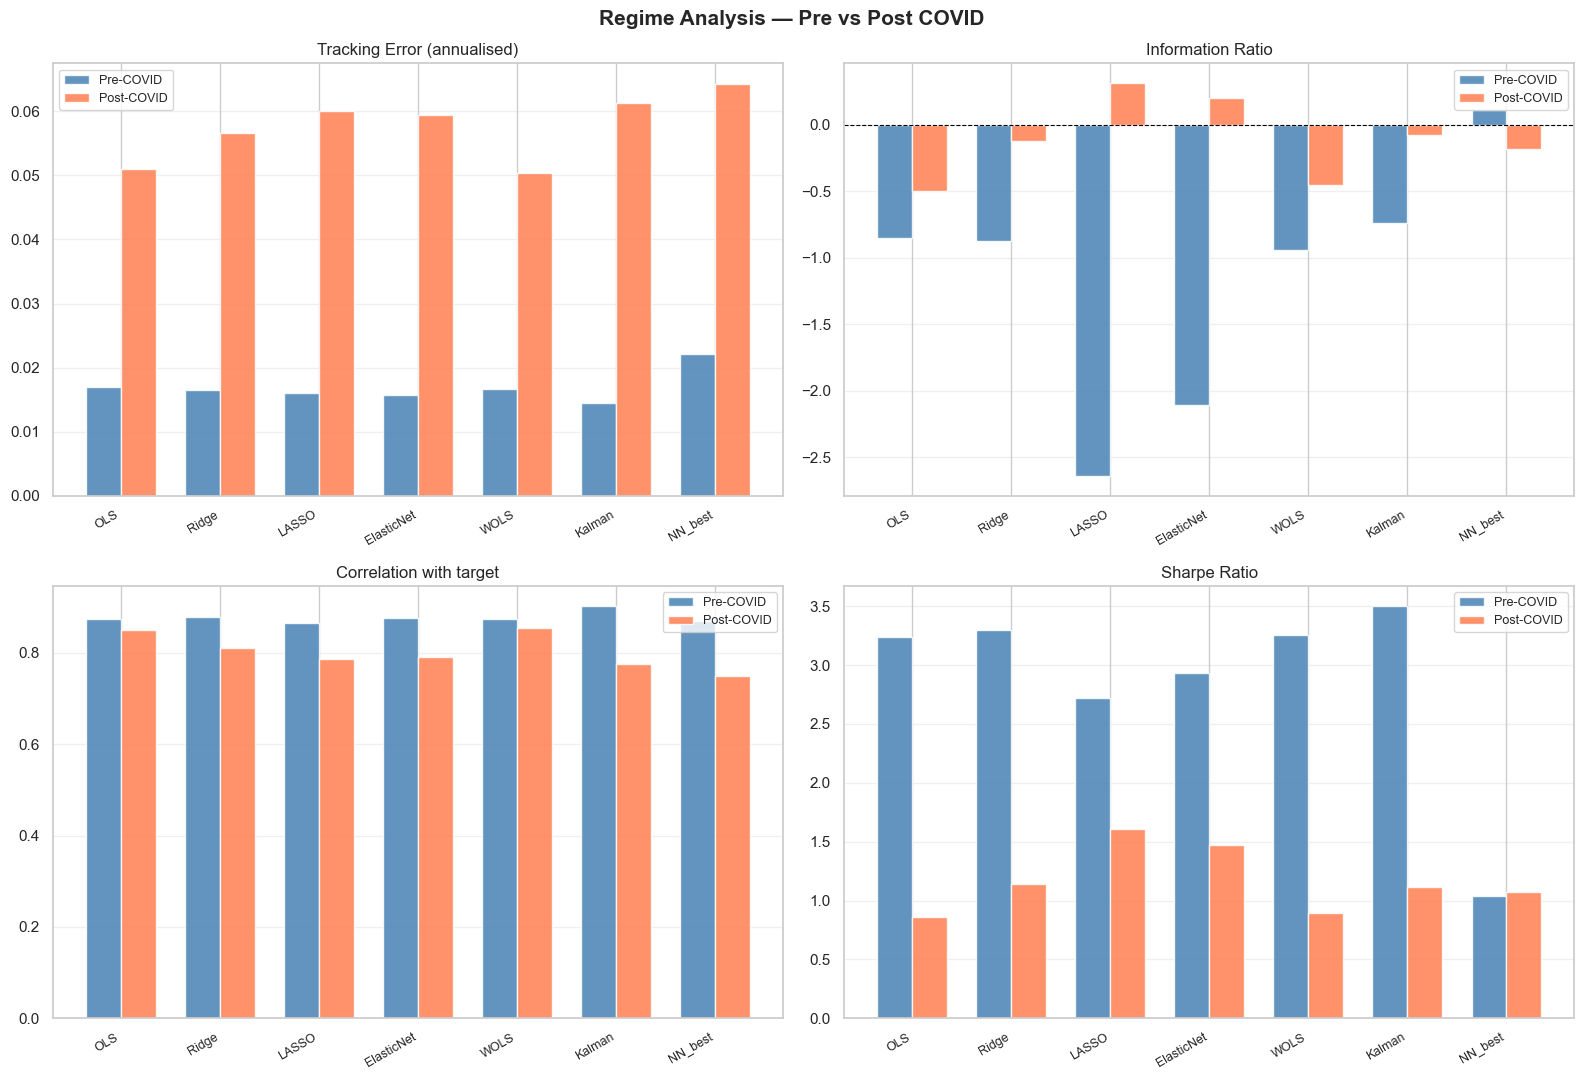

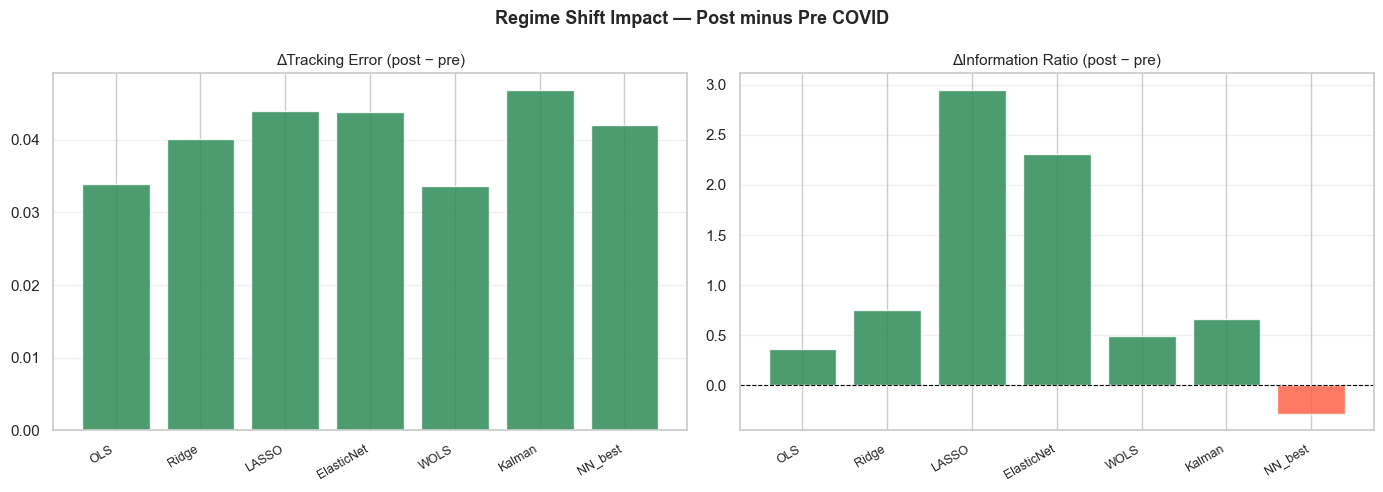

In [24]:
from utils import inline_figures
from utils.evaluation import plot_regime_analysis
with inline_figures():
    plot_regime_analysis(regime_df, save_prefix='regime')


## Regime Analysis — Interpretation

### Tracking Error — degrades for all models, but unevenly

TE roughly triples or quadruples for every model moving from pre- to
post-COVID. This is expected: the March 2020 crash and the subsequent
volatility make replication intrinsically harder. The interesting signal
is *who degrades least*: **WOLS and OLS post the lowest post-COVID TE
(~0.050)**, suggesting that simpler, more stable weight structures are
more resilient when the regime shifts abruptly. Among linear models,
LASSO and ElasticNet suffer the most (~0.060 post-COVID), likely because
L1/L2 regularisation compresses weights in calm markets and then
under-responds when volatility spikes.

---

### Information Ratio — the most informative metric

Pre-COVID, every model posts a **negative IR**. This is expected in a
sustained bull market: during 2019–early 2020 the Monster Index ran a
positive trend that all models systematically underestimated, producing a
consistently negative active return. The magnitude of underestimation,
however, varies significantly across models: **LASSO (−2.64) and
ElasticNet (−2.11) show a much more negative pre-COVID IR than OLS,
Ridge, and WOLS (−0.85 to −0.94)**. This reflects the effect of
regularisation: L1/L2 shrinkage compresses the replica weights in calm
markets, causing the replica to undershoot a trending target by a wide
margin.

Post-COVID the picture partially reverses. **LASSO (+0.31) and
ElasticNet (+0.20) are the only two models with a positive IR in the
post-COVID period**. However, a positive IR in a replication context is
a **yellow flag, not a green one**. A replication strategy is designed
to *match* the target, not beat it — systematic outperformance suggests
either look-ahead bias, overfitting that leaked from the training period,
or simply sampling noise over a short window. With roughly 200 post-COVID
weekly observations, a positive mean active return may not be
statistically distinguishable from zero. The preferred model is therefore
the one with the lowest TE and IR closest to zero, not the highest IR.
This description fits **WOLS and OLS** better than LASSO or ElasticNet.

Kalman remains negative in both regimes, which is surprising given that
it is theoretically designed to track time-varying dynamics. The NN
posts the worst post-COVID IR (−0.56), likely because it learned
patterns specific to the training distribution that do not generalise
under stress.

---

### Correlation — stable across regimes

Correlation is the only metric that does not degrade materially in the
post-COVID period — every model stays above 0.77. **Kalman and NN lead
in the pre-COVID period (≥ 0.90)**, while **OLS and WOLS lead
post-COVID (≥ 0.85)**. The key takeaway is that all models correctly
track the *direction* of the Monster Index; the failure mode is in the
*magnitude*, not the sign.

---

### Sharpe Ratio — generalised collapse with one exception

The replica Sharpe ratio collapses post-COVID for nearly every model.
Among linear models, **LASSO (1.61) and ElasticNet (1.47) maintain the
highest post-COVID Sharpe**, while OLS (0.86) and WOLS (0.89) post the
weakest values. However, consistent with the IR discussion above, a high
Sharpe on the replica in isolation does not imply good replication
quality — it only means the replica itself had a favourable
return-to-risk profile in that subperiod, independently of how well it
tracked the target. Kalman achieves the highest pre-COVID Sharpe (3.50)
but falls sharply to 1.11 post-COVID — confirming that it adapts well in
calm markets but struggles with abrupt regime breaks. The NN posts the
weakest Sharpe values post-COVID, suggesting that the learned patterns
do not generalise under market stress.

---

### Bottom line

The most reliable metrics for evaluating a replication strategy are
**Tracking Error and Correlation**, not IR or Sharpe. On these two
metrics, **WOLS and OLS are the most robust models across regimes**:
they post the lowest post-COVID TE (~0.050) and maintain the highest
correlation in both subperiods (≥ 0.85 post-COVID). LASSO and
ElasticNet show apparent post-COVID strength in Sharpe and IR, but this
is driven by a favourable active return that is statistically fragile
and financially undesirable in a replication context. The additional
complexity of Kalman and the NN does not translate into regime
resilience — simpler, more stable weight structures outperform when the
market environment shifts abruptly.
